In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/indexData.csv')

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
file_path = '/content/drive/MyDrive/Colab/indexData.csv'

df = pd.read_csv(file_path)

print(df.head())
print("\nDataset Shape:", df.shape)

  Index        Date        Open        High         Low       Close  \
0   NYA  1965-12-31  528.690002  528.690002  528.690002  528.690002   
1   NYA  1966-01-03  527.210022  527.210022  527.210022  527.210022   
2   NYA  1966-01-04  527.840027  527.840027  527.840027  527.840027   
3   NYA  1966-01-05  531.119995  531.119995  531.119995  531.119995   
4   NYA  1966-01-06  532.070007  532.070007  532.070007  532.070007   

    Adj Close  Volume  
0  528.690002     0.0  
1  527.210022     0.0  
2  527.840027     0.0  
3  531.119995     0.0  
4  532.070007     0.0  

Dataset Shape: (112457, 8)


Columns: ['Index', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
Shape: (112457, 8)

Accuracy: 0.5311777243662419

Classification Report:
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00     10338
          Up       0.53      1.00      0.69     11713

    accuracy                           0.53     22051
   macro avg       0.27      0.50      0.35     22051
weighted avg       0.28      0.53      0.37     22051


Confusion Matrix:
[[    0 10338]
 [    0 11713]]

New Prediction:
Prediction: Up
Probability of Down: 0.4763
Probability of Up: 0.5237


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


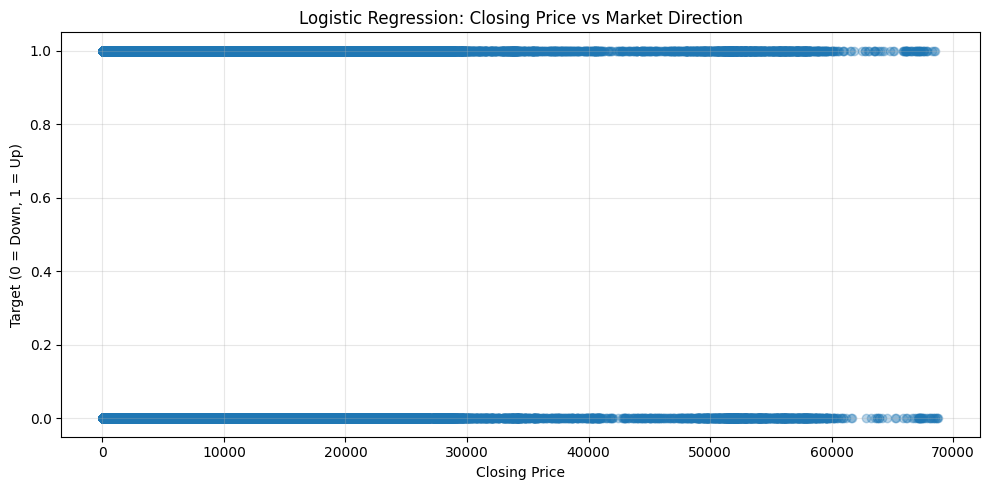

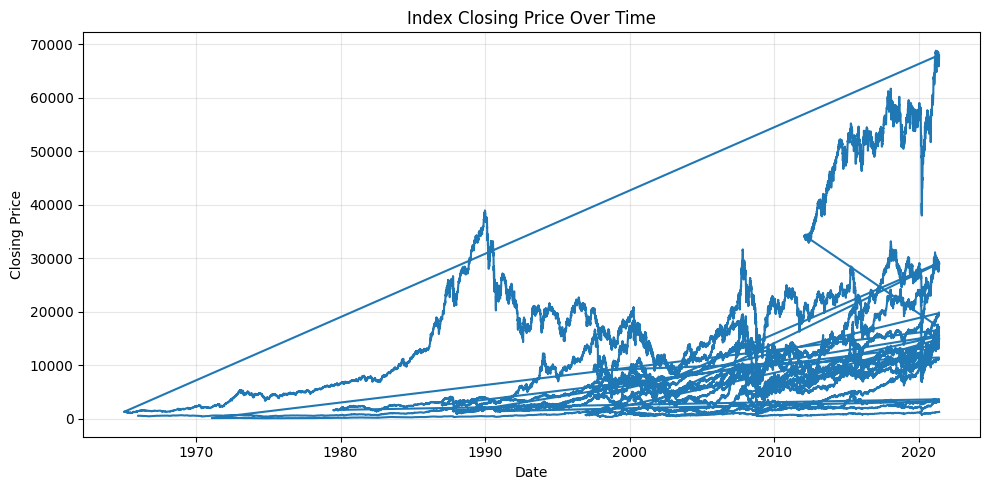

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

file_path = '/content/drive/MyDrive/Colab/indexData.csv'

df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()

print("Columns:", df.columns.tolist())
print("Shape:", df.shape)

df["Date"] = pd.to_datetime(df["Date"])

df = df.dropna(subset=["Open", "High", "Low", "Close", "Volume"])

df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

df = df.iloc[:-1]

X = df[["Open", "High", "Low", "Close", "Volume"]]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Down", "Up"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

new_data = pd.DataFrame({
    "Open": [18000],
    "High": [18200],
    "Low": [17900],
    "Close": [18100],
    "Volume": [1000000]
})

prediction = model.predict(new_data)
probability = model.predict_proba(new_data)

print("\nNew Prediction:")
print("Prediction:", "Up" if prediction[0] == 1 else "Down")
print("Probability of Down:", round(probability[0][0], 4))
print("Probability of Up:", round(probability[0][1], 4))

plt.figure(figsize=(10, 5))

plt.scatter(
    df["Close"],
    df["Target"],
    alpha=0.3
)

plt.xlabel("Closing Price")
plt.ylabel("Target (0 = Down, 1 = Up)")
plt.title("Logistic Regression: Closing Price vs Market Direction")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

plt.plot(
    df["Date"],
    df["Close"]
)

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("Index Closing Price Over Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()